<a href="https://colab.research.google.com/github/shreyasgowdac-319/ML-LAB/blob/main/SVM_Lab6_319.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


iris_df = pd.read_csv('/content/iris (1) (2).csv')

X_iris = iris_df.drop('species', axis=1)
y_iris = iris_df['species']

X_train_iris, X_test_iris, y_train_iris, y_test_iris = train_test_split(X_iris, y_iris, test_size=0.2, random_state=42)

Accuracy Score (Linear Kernel): 1.0000
Confusion Matrix (Linear Kernel):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


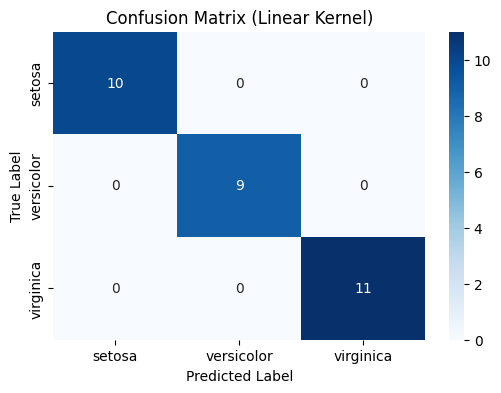

In [ ]:
l
svm_linear = SVC(kernel='linear', random_state=42)
svm_linear.fit(X_train_iris, y_train_iris)

y_pred_linear = svm_linear.predict(X_test_iris)

accuracy_linear = accuracy_score(y_test_iris, y_pred_linear)
print(f"Accuracy Score (Linear Kernel): {accuracy_linear:.4f}")

conf_matrix_linear = confusion_matrix(y_test_iris, y_pred_linear)
print("Confusion Matrix (Linear Kernel):")
print(conf_matrix_linear)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_linear, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_linear.classes_, yticklabels=svm_linear.classes_)
plt.title('Confusion Matrix (Linear Kernel)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Accuracy Score (RBF Kernel): 1.0000
Confusion Matrix (RBF Kernel):
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


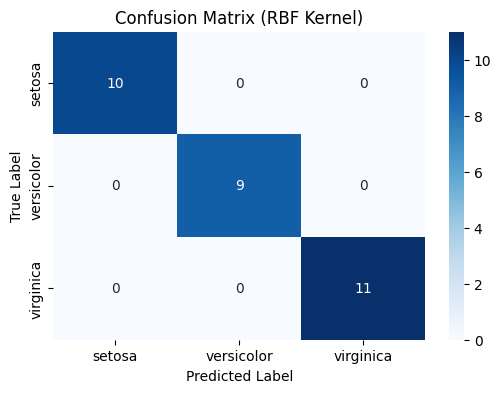

In [ ]:

svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train_iris, y_train_iris)

y_pred_rbf = svm_rbf.predict(X_test_iris)

# Calculate and display accuracy score
accuracy_rbf = accuracy_score(y_test_iris, y_pred_rbf)
print(f"Accuracy Score (RBF Kernel): {accuracy_rbf:.4f}")

# Display confusion matrix
conf_matrix_rbf = confusion_matrix(y_test_iris, y_pred_rbf)
print("Confusion Matrix (RBF Kernel):")
print(conf_matrix_rbf)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix_rbf, annot=True, fmt='d', cmap='Blues',
            xticklabels=svm_rbf.classes_, yticklabels=svm_rbf.classes_)
plt.title('Confusion Matrix (RBF Kernel)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:

drug_df = pd.read_csv('/content/drug.csv')

le = LabelEncoder()
for column in drug_df.columns:
    if drug_df[column].dtype == 'object':
        drug_df[column] = le.fit_transform(drug_df[column])

X_drug = drug_df.drop('Drug', axis=1)
y_drug = drug_df['Drug']

X_train_drug, X_test_drug, y_train_drug, y_test_drug = train_test_split(X_drug, y_drug, test_size=0.2, random_state=42)

Accuracy Score (Drug Dataset): 0.6250
Confusion Matrix (Drug Dataset):
[[ 0  0  0  6  0]
 [ 0  0  0  3  0]
 [ 0  0  0  4  1]
 [ 0  0  0 10  1]
 [ 0  0  0  0 15]]


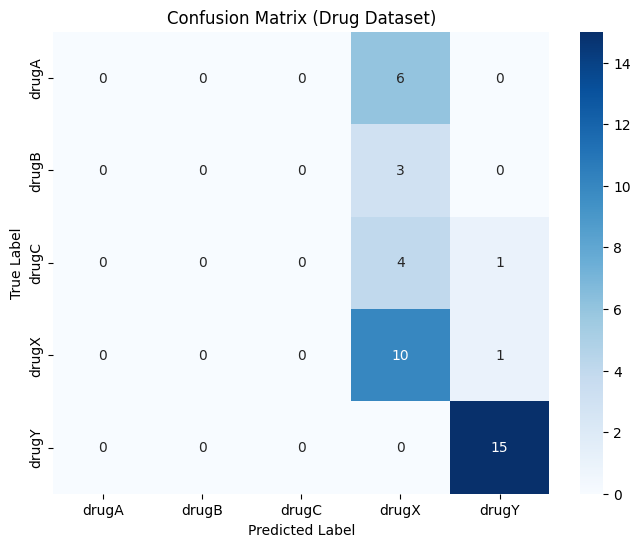

In [ ]:

svm_drug = SVC(kernel='rbf', random_state=42, probability=True) # probability=True for ROC curve
svm_drug.fit(X_train_drug, y_train_drug)

y_pred_drug = svm_drug.predict(X_test_drug)

accuracy_drug = accuracy_score(y_test_drug, y_pred_drug)
print(f"Accuracy Score (Drug Dataset): {accuracy_drug:.4f}")

conf_matrix_drug = confusion_matrix(y_test_drug, y_pred_drug)
print("Confusion Matrix (Drug Dataset):")
print(conf_matrix_drug)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_drug, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.inverse_transform(svm_drug.classes_),
            yticklabels=le.inverse_transform(svm_drug.classes_))
plt.title('Confusion Matrix (Drug Dataset)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

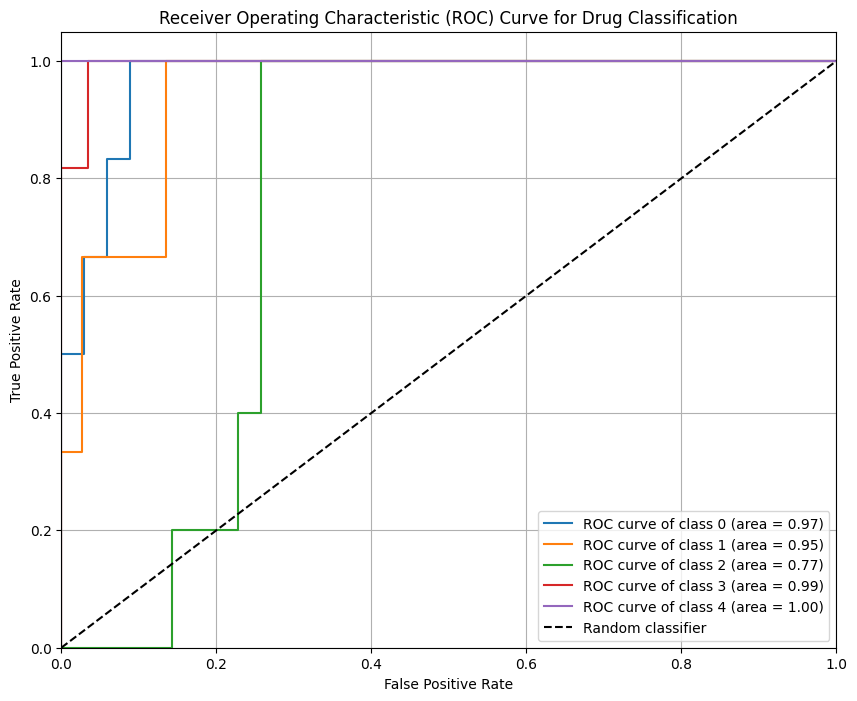

Average AUC Score (Drug Dataset): 0.9363


In [ ]:
y_proba_drug = svm_drug.predict_proba(X_test_drug)



fpr = dict()
tpr = dict()
roc_auc = dict()

y_test_drug_encoded = le.fit_transform(y_test_drug)

for i in range(len(svm_drug.classes_)):
    fpr[i], tpr[i], _ = roc_curve(y_test_drug_encoded, y_proba_drug[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 8))
for i in range(len(svm_drug.classes_)):
    plt.plot(fpr[i], tpr[i], label=f'ROC curve of class {le.inverse_transform([i])[0]} (area = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve for Drug Classification')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

avg_roc_auc = sum(roc_auc.values()) / len(roc_auc)
print(f"Average AUC Score (Drug Dataset): {avg_roc_auc:.4f}")